
# Phase 1: Data Preparation

In this phase, we will load and prepare the HAM10000 dataset.

In [58]:
# Import libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split

**Check TensorFlow and GPU**

In [59]:
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**Set dataset paths**

In [60]:
project_path = "/home/arslan/projects/skin-lesion-classifier"

metadata_path = project_path + "/data/raw/HAM10000_metadata.csv"

image_folder = project_path + "/data/raw/HAM10000_images"

In [61]:
#Check paths

print("Metadata exists:", os.path.exists(metadata_path))
print("Image folder exists:", os.path.exists(image_folder))

Metadata exists: True
Image folder exists: True


In [62]:
#Load the metadata

df = pd.read_csv(metadata_path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000550,ISIC_0024306,nv,follow_up,45.0,male,trunk
1,HAM_0003577,ISIC_0024307,nv,follow_up,50.0,male,lower extremity
2,HAM_0001477,ISIC_0024308,nv,follow_up,55.0,female,trunk
3,HAM_0000484,ISIC_0024309,nv,follow_up,40.0,male,trunk
4,HAM_0003350,ISIC_0024310,mel,histo,60.0,male,chest


In [63]:
#Check column names

print(df.columns.tolist())

['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


In [64]:
#Check class distribution

print(df["dx"].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [65]:
#Find all image files

image_paths = {}

for filename in os.listdir(image_folder):
    if filename.endswith(".jpg"):
        image_id = filename.replace(".jpg", "")
        image_paths[image_id] = image_folder + "/" + filename

print("Total images found:", len(image_paths))

Total images found: 10015


In [66]:
#Add image paths to metadata

df["image_path"] = df["image_id"].map(image_paths)

df[["image_id", "dx", "image_path"]].head()

,image_id,dx,image_path
0,ISIC_0024306,nv,/home/arslan/projects/skin-lesion-classifier/d...
1,ISIC_0024307,nv,/home/arslan/projects/skin-lesion-classifier/d...
2,ISIC_0024308,nv,/home/arslan/projects/skin-lesion-classifier/d...
3,ISIC_0024309,nv,/home/arslan/projects/skin-lesion-classifier/d...
4,ISIC_0024310,mel,/home/arslan/projects/skin-lesion-classifier/d...


In [67]:
#Check missing images

print("Missing images:", df["image_path"].isnull().sum())

Missing images: 0


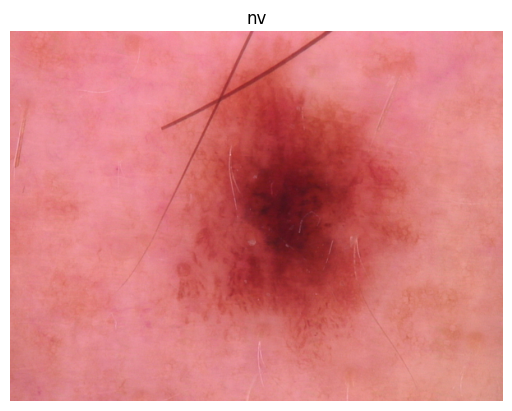

In [68]:
#Display one image

first_image = df["image_path"].iloc[0]

image = tf.keras.utils.load_img(first_image)

plt.imshow(image)
plt.title(df["dx"].iloc[0])
plt.axis("off")
plt.show()

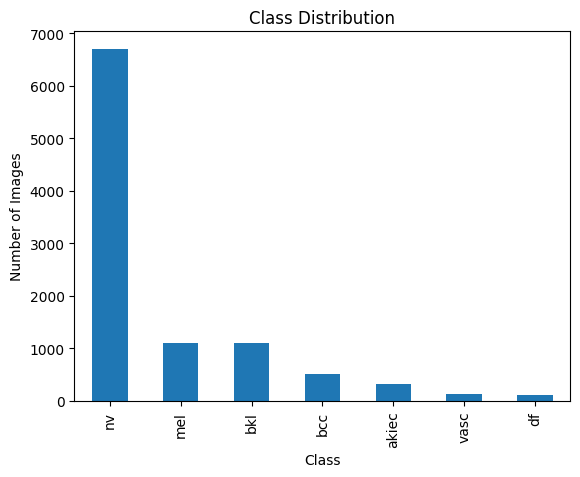

In [69]:
# class distribution graph

df["dx"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [70]:
#Encode class labels

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["dx"])

df[["dx", "label"]].head()

,dx,label
0,nv,5
1,nv,5
2,nv,5
3,nv,5
4,mel,4


In [71]:
for number, class_name in enumerate(label_encoder.classes_):
    print(number, "=", class_name)

0 = akiec
1 = bcc
2 = bkl
3 = df
4 = mel
5 = nv
6 = vasc


**Create Lesion-Level Data**

In [72]:
lesion_df = df[["lesion_id", "label"]].drop_duplicates()

multiple_labels = (
    df.groupby("lesion_id")["label"]
    .nunique()
    .gt(1)
    .sum()
)

print("Unique lesions:", len(lesion_df))
print("Lesions with multiple labels:", multiple_labels)

Unique lesions: 7470
Lesions with multiple labels: 0


**Split Unique Lesions into Training and Temporary Sets**

In [73]:
train_lesion_df, temp_lesion_df = train_test_split(
    lesion_df,
    test_size=0.30,
    random_state=42,
    stratify=lesion_df["label"]
)

print("Training lesions:", len(train_lesion_df))
print("Temporary lesions:", len(temp_lesion_df))

Training lesions: 5229
Temporary lesions: 2241


**Split Temporary Lesions into Validation and Test Sets**

In [74]:
val_lesion_df, test_lesion_df = train_test_split(
    temp_lesion_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_lesion_df["label"]
)

print("Validation lesions:", len(val_lesion_df))
print("Testing lesions:", len(test_lesion_df))

Validation lesions: 1120
Testing lesions: 1121


**Create Image-Level Training, Validation and Test DataFrames**

In [75]:
train_df = df[df["lesion_id"].isin(train_lesion_df["lesion_id"])].copy()
val_df = df[df["lesion_id"].isin(val_lesion_df["lesion_id"])].copy()
test_df = df[df["lesion_id"].isin(test_lesion_df["lesion_id"])].copy()

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

Training images: 7014
Validation images: 1509
Testing images: 1492


**Check Lesion Overlap**

In [76]:
train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])

print("Train-Val overlap:", len(train_lesions & val_lesions))
print("Train-Test overlap:", len(train_lesions & test_lesions))
print("Val-Test overlap:", len(val_lesions & test_lesions))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


**Confirm Total Number of Images**

In [77]:
total_images = len(train_df) + len(val_df) + len(test_df)

print("Total images:", total_images)

Total images: 10015


**Check Class Distribution in Each Split**

In [78]:
print("Training distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["label"].value_counts().sort_index())

print("\nTesting distribution:")
print(test_df["label"].value_counts().sort_index())

Training distribution:
label
0     235
1     365
2     752
3      79
4     792
5    4690
6     101
Name: count, dtype: int64

Validation distribution:
label
0      50
1      73
2     180
3      17
4     162
5    1009
6      18
Name: count, dtype: int64

Testing distribution:
label
0      42
1      76
2     167
3      19
4     159
5    1006
6      23
Name: count, dtype: int64


**Calculate Class Weights**

In [79]:
from sklearn.utils.class_weight import compute_class_weight

class_numbers = np.unique(train_df["label"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=class_numbers,
    y=train_df["label"]
)

#Convert weights to simple Python numbers

class_weight_dict = {
    int(class_number): float(weight)
    for class_number, weight in zip(class_numbers, weights)
}

print(class_weight_dict)

{0: 4.263829787234043, 1: 2.745205479452055, 2: 1.3324468085106382, 3: 12.683544303797468, 4: 1.2651515151515151, 5: 0.21364605543710022, 6: 9.92079207920792}


**Set image size and batch size**

In [80]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 32


**Training Image Generator / Data Augmentation**

In [81]:
#defines normalization and augmentation for training images

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,      # normalize pixels from 0–255 to 0–1
    rotation_range=20,      # randomly rotate images
    zoom_range=0.1,         # randomly zoom images
    horizontal_flip=True    # randomly flip images
)

**Validation & Test Generator**

In [82]:
#defines only normalization for validation and test images

test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

Training generator settings define augmentation and normalization, while validation/test generator settings define only normalization.

**Create Training Generator**

In [83]:
#loads training images and labels in batches

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=True
)

Found 7014 validated image filenames.


**Create Validation Generator**

In [84]:
#loads validation images and labels in batches

validation_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

Found 1509 validated image filenames.


**Create Test Generator**

In [85]:
#loads test images and labels in batches for final evaluation

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

Found 1492 validated image filenames.


Training, validation, and test generators load their respective images and labels in batches for training, checking, and final evaluation.

**Check one training batch**

In [86]:
batch_images, batch_labels = next(train_generator)

print("Image shape:", batch_images.shape)
print("Label shape:", batch_labels.shape)
print("Minimum pixel value:", batch_images.min())
print("Maximum pixel value:", batch_images.max())

Image shape: (32, 224, 224, 3)
Label shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


**Display Augmented Images**

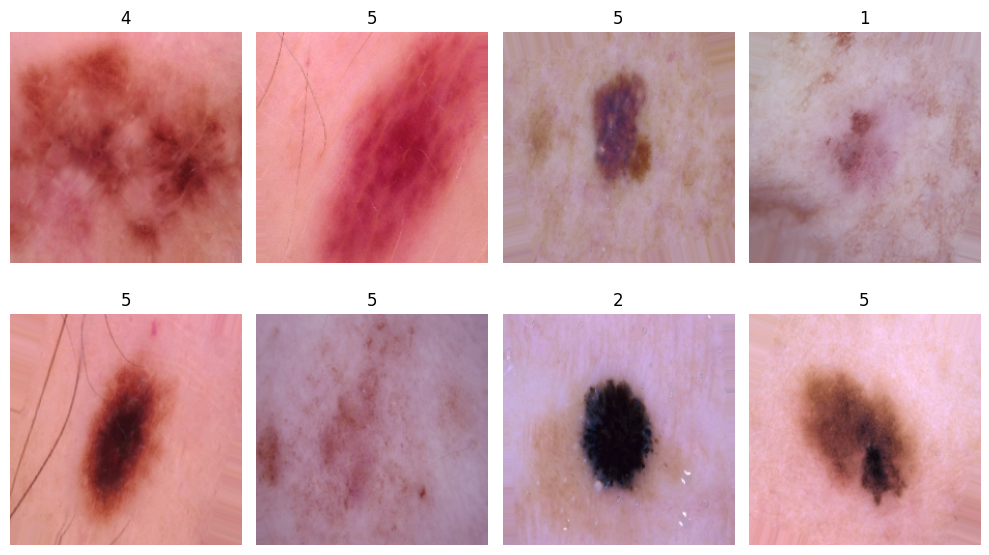

In [87]:
plt.figure(figsize=(10, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(batch_images[i])
    plt.title(int(batch_labels[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Results

In [88]:
print("Total images:", len(df))
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))
print("Missing images:", df["image_path"].isnull().sum())
print("Number of classes:", df["label"].nunique())

Total images: 10015
Training images: 7014
Validation images: 1509
Test images: 1492
Missing images: 0
Number of classes: 7


In [89]:
processed_path = project_path + "/data/processed"
os.makedirs(processed_path, exist_ok=True)

train_df.to_csv(processed_path + "/train.csv", index=False)
val_df.to_csv(processed_path + "/validation.csv", index=False)
test_df.to_csv(processed_path + "/test.csv", index=False)

print("Splits saved successfully.")

Splits saved successfully.
